In [1]:
import cv2
import numpy as np
import json
from pathlib import Path
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt


def process_floor_plan(image_path, display=True):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None

    # --- 1. Threshold walls ---
    _, wall_mask = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY_INV)

    # --- 2. Skeletonize walls ---
    skeleton = skeletonize(wall_mask // 255).astype(np.uint8) * 255

    # --- 3. Find room boundaries (contours) ---
    contours, _ = cv2.findContours(wall_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    rooms = [
        cv2.approxPolyDP(c, 3, True).reshape(-1, 2).tolist()
        for c in contours
        if cv2.contourArea(c) > 500
    ]

    # --- 4. Detect doors (gap-based heuristic) ---
    doors = []
    lines = cv2.HoughLinesP(
        skeleton, 1, np.pi / 180, threshold=30, minLineLength=20, maxLineGap=5
    )
    if lines is not None:
        for l in lines:
            x1, y1, x2, y2 = l[0]
            if np.hypot(x2 - x1, y2 - y1) < 50:  # short segment = possible door
                doors.append([(int(x1), int(y1)), (int(x2), int(y2))])

    # --- Visualization ---
    if display:
        vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

        # draw walls (red)
        vis[skeleton > 0] = (0, 0, 255)

        # draw room contours (green)
        for r in rooms:
            cv2.polylines(vis, [np.array(r, np.int32)], True, (0, 255, 0), 2)

        # draw doors (blue)
        for p1, p2 in doors:
            cv2.line(vis, p1, p2, (255, 0, 0), 2)

        plt.figure(figsize=(8, 8))
        plt.title(f"Processed {Path(image_path).name}")
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

    return {"image": str(image_path), "rooms": rooms, "doors": doors}


def process_dataset(root_dir, output_json="dataset.json", display=True):
    dataset = []
    for img_file in Path(root_dir).glob("*.png"):
        data = process_floor_plan(img_file, display=display)
        if data:
            dataset.append(data)

    with open(output_json, "w") as f:
        json.dump(dataset, f, indent=2)

    return dataset


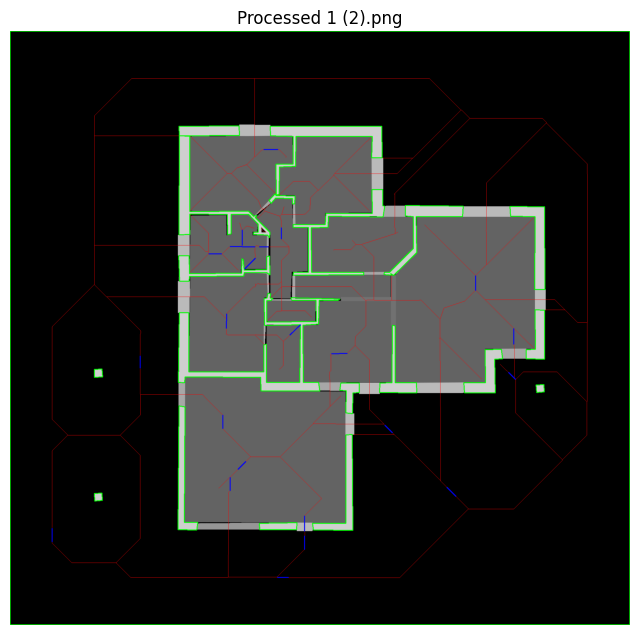

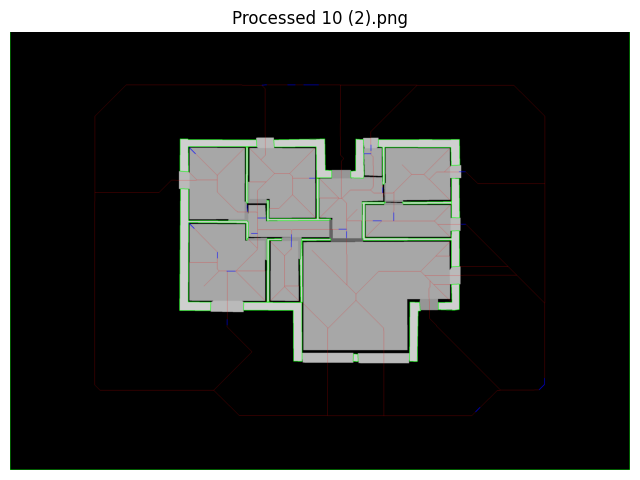

KeyboardInterrupt: 

In [2]:
# Run dataset processing (walls, doors, room boundaries)
root_dir = "dataset/floor_plan_arch/Y"  # update if path differs
output_file = "floorplan_dataset.json"

dataset = process_dataset(root_dir, output_json=output_file, display=True)

print(f"Processed {len(dataset)} floor plans")
print(f"Dataset saved to {output_file}")

# Preview first entry
if dataset:
    from pprint import pprint

    pprint(dataset[0])


In [3]:
# --- Feature extraction helper ---
COLOR_RANGES = {
    "walls": ([200, 200, 200], [255, 255, 255]),
    "doors": ([0, 100, 200], [50, 180, 255]),
    "windows": ([0, 200, 200], [50, 255, 255]),
    "interior": ([0, 100, 100], [100, 200, 200]),
    "garage": ([0, 150, 0], [50, 255, 50]),
    "special": ([0, 0, 150], [50, 50, 255]),
}


def mask_from_range(image, lower, upper):
    lower = np.array(lower, dtype=np.uint8)
    upper = np.array(upper, dtype=np.uint8)
    return cv2.inRange(image, lower, upper)


def extract_features(y_image_path):
    img = cv2.imread(str(y_image_path))
    if img is None:
        raise FileNotFoundError(y_image_path)

    masks = {}
    for key, (low, high) in COLOR_RANGES.items():
        masks[key] = mask_from_range(img, low, high)

    contours, _ = cv2.findContours(
        masks["interior"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    rooms = []
    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx, cy = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
                rooms.append({"centroid": (cx, cy), "contour": cnt.tolist()})

    return {"rooms": rooms, "masks": masks}


# --- Filtered dataset processor ---
def process_dataset_filtered(root_dir, output_json="dataset.json", display=False):
    dataset = []
    y_dir = Path(root_dir)

    for y_file in sorted(y_dir.glob("*.png")):
        try:
            features = extract_features(y_file)
        except Exception as e:
            print(f"Skipping {y_file.name} (error: {e})")
            continue

        wall_pixels = cv2.countNonZero(features["masks"]["walls"])
        room_count = len(features["rooms"])

        if wall_pixels < 1000 or room_count == 0:
            print(f"Skipping {y_file.name} (no valid walls/rooms)")
            continue

        dataset.append(
            {
                "file": y_file.name,
                "rooms": features["rooms"],
                "masks_summary": {
                    k: int(cv2.countNonZero(v)) for k, v in features["masks"].items()
                },
            }
        )

        if display:
            img = cv2.imread(str(y_file))
            overlay = img.copy()
            for room in features["rooms"]:
                cv2.drawContours(
                    overlay, [np.array(room["contour"])], -1, (0, 255, 0), 2
                )
                cv2.circle(overlay, room["centroid"], 4, (0, 0, 255), -1)
            plt.figure(figsize=(6, 6))
            plt.title(y_file.name)
            plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(dataset, f, indent=2, ensure_ascii=False)

    return dataset


# --- Run ---
root_dir = "dataset/floor_plan_arch/Y"
output_file = "filtered_floorplans.json"

dataset = process_dataset_filtered(root_dir, output_json=output_file, display=True)

print(f"✅ Processed {len(dataset)} valid floor plans")
print(f"💾 Dataset saved to {output_file}")


Skipping 1 (2).png (no valid walls/rooms)
Skipping 10 (2).png (no valid walls/rooms)
Skipping 100 (2).png (no valid walls/rooms)
Skipping 101 (2).png (no valid walls/rooms)
Skipping 102 (2).png (no valid walls/rooms)
Skipping 103 (2).png (no valid walls/rooms)
Skipping 104 (2).png (no valid walls/rooms)
Skipping 105 (2).png (no valid walls/rooms)
Skipping 106 (2).png (no valid walls/rooms)
Skipping 107 (2).png (no valid walls/rooms)
Skipping 108 (2).png (no valid walls/rooms)
Skipping 109 (2).png (no valid walls/rooms)
Skipping 11 (2).png (no valid walls/rooms)
Skipping 110 (2).png (no valid walls/rooms)
Skipping 111 (2).png (no valid walls/rooms)
Skipping 112 (2).png (no valid walls/rooms)
Skipping 113 (2).png (no valid walls/rooms)
Skipping 114 (2).png (no valid walls/rooms)
Skipping 115 (2).png (no valid walls/rooms)
Skipping 116 (2).png (no valid walls/rooms)
Skipping 117 (2).png (no valid walls/rooms)
Skipping 118 (2).png (no valid walls/rooms)
Skipping 119 (2).png (no valid walls

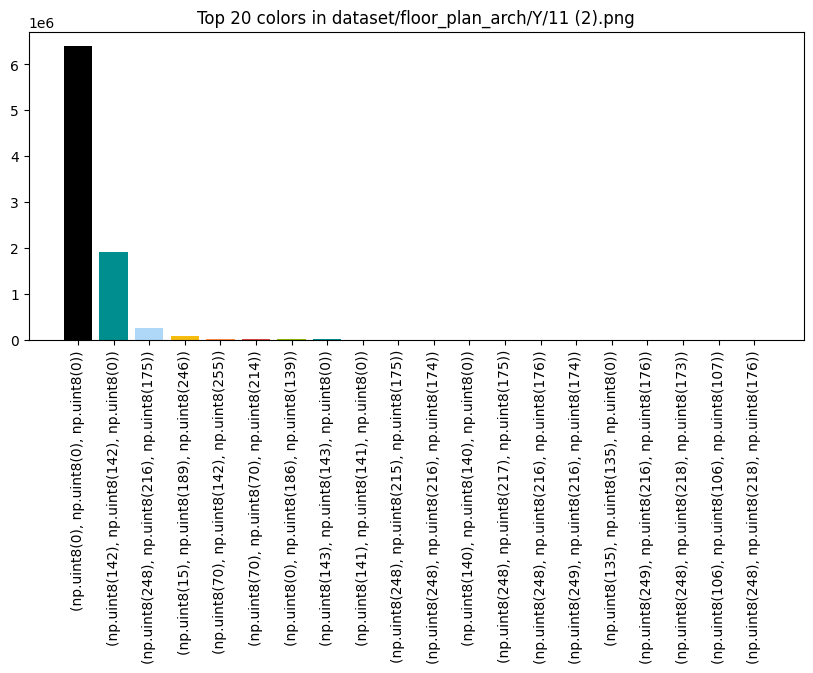

Most common colors (BGR):
(np.uint8(0), np.uint8(0), np.uint8(0)) -> 6393353 pixels
(np.uint8(142), np.uint8(142), np.uint8(0)) -> 1904462 pixels
(np.uint8(248), np.uint8(216), np.uint8(175)) -> 247553 pixels
(np.uint8(15), np.uint8(189), np.uint8(246)) -> 82905 pixels
(np.uint8(70), np.uint8(142), np.uint8(255)) -> 17805 pixels
(np.uint8(70), np.uint8(70), np.uint8(214)) -> 14765 pixels
(np.uint8(0), np.uint8(186), np.uint8(139)) -> 10894 pixels
(np.uint8(143), np.uint8(143), np.uint8(0)) -> 4331 pixels
(np.uint8(141), np.uint8(141), np.uint8(0)) -> 2151 pixels
(np.uint8(248), np.uint8(215), np.uint8(175)) -> 930 pixels
(np.uint8(248), np.uint8(216), np.uint8(174)) -> 666 pixels
(np.uint8(140), np.uint8(140), np.uint8(0)) -> 641 pixels
(np.uint8(248), np.uint8(217), np.uint8(175)) -> 609 pixels
(np.uint8(248), np.uint8(216), np.uint8(176)) -> 600 pixels
(np.uint8(249), np.uint8(216), np.uint8(174)) -> 444 pixels
(np.uint8(135), np.uint8(135), np.uint8(0)) -> 429 pixels
(np.uint8(249),

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


def get_dominant_colors(image_path, top_k=15):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(image_path)

    # Flatten image -> list of BGR tuples
    pixels = img.reshape(-1, 3)
    pixels = [tuple(p) for p in pixels]

    # Count frequencies
    counter = Counter(pixels)
    most_common = counter.most_common(top_k)

    # Convert to array for plotting
    colors = np.array([c[0] for c in most_common], dtype=np.uint8)
    freqs = [c[1] for c in most_common]

    # Plot bar chart
    plt.figure(figsize=(10, 4))
    plt.bar(
        range(len(colors)),
        freqs,
        color=[(c[2] / 255, c[1] / 255, c[0] / 255) for c in colors],
    )
    plt.xticks(range(len(colors)), [str(tuple(c)) for c in colors], rotation=90)
    plt.title(f"Top {top_k} colors in {image_path}")
    plt.show()

    return most_common


# Example usage on a Y image
y_img_path = "dataset/floor_plan_arch/Y/11 (2).png"
top_colors = get_dominant_colors(y_img_path, top_k=20)

print("Most common colors (BGR):")
for color, freq in top_colors:
    print(color, "->", freq, "pixels")


In [ ]:
import cv2
import numpy as np
from collections import Counter


def get_dominant_colors(image_path, top_n=10):
    """
    Finds the most common colors in an image.
    Returns top_n colors in BGR format.
    """
    img = cv2.imread(image_path)
    if img is None:
        return []

    pixels = img.reshape(-1, 3)
    counter = Counter(map(tuple, pixels))
    return counter.most_common(top_n)


def create_color_mask(image, target_color, tolerance=20):
    """
    Creates a mask for pixels close to the target_color (BGR).
    """
    lower = np.array([max(c - tolerance, 0) for c in target_color], dtype=np.uint8)
    upper = np.array([min(c + tolerance, 255) for c in target_color], dtype=np.uint8)
    mask = cv2.inRange(image, lower, upper)
    return mask


def should_process_image(image_path, tolerance=20, min_matches=3):
    """
    Decides whether an image follows the expected color scheme.
    Returns True if it should be processed, else False.
    """
    # Get dominant colors
    common_colors = get_dominant_colors(image_path, top_n=20)
    if not common_colors:
        return False

    # Expected base colors (from your dataset analysis)
    expected_colors = [
        (0, 0, 0),  # black
        (142, 142, 0),  # yellow
        (248, 216, 175),  # beige
        (15, 189, 246),  # light blue
        (70, 142, 255),  # dark blue
        (0, 186, 139),  # green
    ]

    # Count matches
    found = 0
    for color, _ in common_colors:
        for exp in expected_colors:
            if all(abs(c - e) < tolerance for c, e in zip(color, exp)):
                found += 1
                break

    return found >= min_matches


In [ ]:
for i in range(1, 122):
    image_path = f"dataset/floor_plan_arch/Y/{i} (2).png"

    if should_process_image(image_path):
        walls, doors, room_mask = process_floor_plan(image_path)
        if walls is not None:
            # simulate_crowd(image_path)
            print("simulate crowd")
    else:
        print(f"Skipped {image_path} ❌ (color scheme not matching)")
